# Analyze results from $k$ and $m$ grid search

It requires that the parameter estimation has been completed and there exists a file with those results. Edit the location of those files below.

## Load required packages

In [2]:
%matplotlib widget
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import numpy as np
from statsmodels.formula import api as smf
import os
import seaborn as sns
from scipy.stats import ttest_ind
from estimator import Estimator

## User-defined parameters

In [6]:
growth_data_file = "data/growth_data_df.csv"
config_file = "config_files/config_km.json"

result_path = "results_path/"

# figure_save_path = "figures/" # Set to None to not save figures
figure_save_path = None
best_value_save_path = "bests/" # Set to None to not save
best_value_save_path = None

## Setup

In [4]:
groups = ["Grp. B1 nude (100% C1)", "Grp. B2 nude (80% C1; 20% C11)", "Grp. B3 nude (50% C1; 50% C11)", "Grp. B4 nude (20% C1; 80% C11)", "Grp. B5 nude (100% C11)"]
growth_df = pd.read_csv(growth_data_file)
exclude = [456, 458, 461, 464, 471, 474, 478, 482, 483, 426, 428, 429, 430, 434, 437, 438, 442, 443, 451, 642, 662]
growth_df = growth_df[~(growth_df["id"].isin(exclude))]
es = Estimator(config_file)

## Read in and prep data

In [7]:
df = []
for fname in [f for f in os.listdir(result_path)]:
    temp = pd.read_csv(result_path+fname)
    temp = temp[~(temp["id"].isin(exclude))]
    df += [temp]
df = pd.concat(df)
df = df.drop_duplicates()
df["error"] = df["error"].astype(float)
df

,group,id,g1,g11,m,k,error,winner
0,Grp. B2 nude (80% C1; 20% C11),460,0.166,0.127,-0.005,0.165,8.112252e+05,0.0
1,Grp. B2 nude (80% C1; 20% C11),462,0.166,0.127,-0.005,0.165,4.894221e+03,0.0
2,Grp. B2 nude (80% C1; 20% C11),463,0.166,0.127,-0.005,0.165,3.904548e+05,0.0
3,Grp. B2 nude (80% C1; 20% C11),465,0.166,0.127,-0.005,0.165,2.872781e+03,0.0
4,Grp. B2 nude (80% C1; 20% C11),460,0.166,0.127,-0.005,0.170,8.685732e+05,0.0
...,...,...,...,...,...,...,...,...
23192,Grp. B4 nude (20% C1; 80% C11),472,0.171,0.142,0.000,1.000,6.337426e+08,0.0
23193,Grp. B4 nude (20% C1; 80% C11),473,0.171,0.142,0.000,1.000,9.518712e+08,0.0
23194,Grp. B4 nude (20% C1; 80% C11),475,0.171,0.142,0.000,1.000,1.100495e+09,0.0
23195,Grp. B4 nude (20% C1; 80% C11),476,0.171,0.142,0.000,1.000,4.574806e+08,0.0


## Find the top $n$ tuples with lowest error

In [8]:
n = 100
bests = []
for mid in df["id"].unique():
    m_df = df[df["id"] == mid]
    m_df = m_df.sort_values("error").reset_index()
    cutoff = m_df.loc[(n-1),"error"]
    m_df = m_df[m_df["error"] <= cutoff]
    bests += [m_df]
bests = pd.concat(bests)
bests = bests.sort_values(["group", "id"])
bests

,index,group,id,g1,g11,m,k,error,winner
0,1692,Grp. B2 nude (80% C1; 20% C11),460,0.166,0.142,-0.025,-0.010,8686.370697,0.0
1,868,Grp. B2 nude (80% C1; 20% C11),460,0.166,0.141,-0.025,-0.010,8704.985181,0.0
2,8,Grp. B2 nude (80% C1; 20% C11),460,0.166,0.127,-0.020,-0.010,8749.460075,0.0
3,1688,Grp. B2 nude (80% C1; 20% C11),460,0.166,0.142,-0.025,-0.015,8805.163177,0.0
4,864,Grp. B2 nude (80% C1; 20% C11),460,0.166,0.141,-0.025,-0.015,8828.586690,0.0
...,...,...,...,...,...,...,...,...,...
95,33036,Grp. B4 nude (20% C1; 80% C11),477,0.166,0.142,-0.155,0.120,5744.162532,0.0
96,32492,Grp. B4 nude (20% C1; 80% C11),477,0.166,0.142,-0.145,0.115,5746.957048,0.0
97,29361,Grp. B4 nude (20% C1; 80% C11),477,0.166,0.127,-0.125,0.105,5747.386683,0.0
98,33590,Grp. B4 nude (20% C1; 80% C11),477,0.166,0.142,-0.165,0.125,5751.585504,0.0


In [6]:
if best_value_save_path:
    bests.to_csv(best_value_save_path+"km_{}.csv".format(n))

## Plot $k$ and $m$ distributions per group

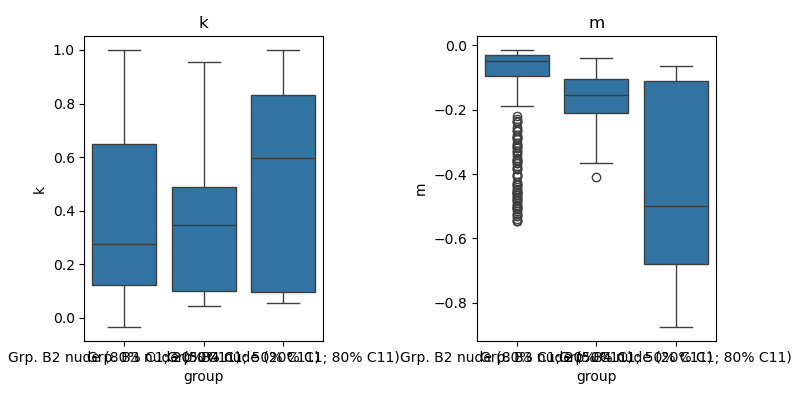

In [11]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))
sns.boxplot(bests, x="group", y="k", ax=axes[0])
axes[0].set_title("k")
sns.boxplot(bests, x="group", y="m", ax=axes[1])
axes[1].set_title("m")
plt.tight_layout()
plt.show()

## Calculate significant differences between $k$ and $m$ per group

In [44]:
print("k B2 vs B3:", ttest_ind(bests[bests["group"]==groups[1]]["k"], bests[bests["group"]==groups[2]]["k"]).pvalue)
print("k B2 vs B4:", ttest_ind(bests[bests["group"]==groups[1]]["k"], bests[bests["group"]==groups[3]]["k"]).pvalue)
print("k B3 vs B4:", ttest_ind(bests[bests["group"]==groups[2]]["k"], bests[bests["group"]==groups[3]]["k"]).pvalue)

print("m B2 vs B3:", ttest_ind(bests[bests["group"]==groups[1]]["m"], bests[bests["group"]==groups[2]]["m"]).pvalue)
print("m B2 vs B4:", ttest_ind(bests[bests["group"]==groups[1]]["m"], bests[bests["group"]==groups[3]]["m"]).pvalue)
print("m B3 vs B4:", ttest_ind(bests[bests["group"]==groups[2]]["m"], bests[bests["group"]==groups[3]]["m"]).pvalue)

k B2 vs B3: 0.0023705131082486335
k B2 vs B4: 1.1558738953481187e-07
k B3 vs B4: 3.6950407108144025e-20
m B2 vs B3: 1.9407688148226548e-08
m B2 vs B4: 4.150752541527255e-70
m B3 vs B4: 7.761746160100144e-75


## Find linear relationships between $k$ and $m$ for each mouse

In [9]:
for mid in bests["id"].unique():
    lr = smf.ols("k~m", bests[bests["id"]==mid]).fit()
    print(bests[bests["id"]==mid].iloc[0]["group"], mid, round(lr.rsquared, 3))

Grp. B2 nude (80% C1; 20% C11) 460 0.099
Grp. B2 nude (80% C1; 20% C11) 462 0.984
Grp. B2 nude (80% C1; 20% C11) 463 1.0
Grp. B2 nude (80% C1; 20% C11) 465 0.829
Grp. B3 nude (50% C1; 50% C11) 466 0.992
Grp. B3 nude (50% C1; 50% C11) 467 0.996
Grp. B3 nude (50% C1; 50% C11) 468 0.995
Grp. B3 nude (50% C1; 50% C11) 469 0.975
Grp. B3 nude (50% C1; 50% C11) 470 0.991
Grp. B4 nude (20% C1; 80% C11) 472 0.999
Grp. B4 nude (20% C1; 80% C11) 473 0.999
Grp. B4 nude (20% C1; 80% C11) 475 0.938
Grp. B4 nude (20% C1; 80% C11) 476 0.995
Grp. B4 nude (20% C1; 80% C11) 477 0.887
